In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

In [3]:
user_artists=pd.read_csv(r"C:\ML_PROJECT\Febrauary\user_artists.dat",sep='\t')

artists=pd.read_csv(r'C:\ML_PROJECT\Febrauary\artists.dat',sep='\t',encoding='latin-1')

user_friends = pd.read_csv("user_friends.dat", sep='\t')

user_tags = pd.read_csv("user_taggedartists.dat", sep='\t')

tags = pd.read_csv("tags.dat", sep='\t',encoding='latin-1')



In [4]:
user_artists.head()

,userID,artistID,weight
0,2,51,13883
1,2,52,11690
2,2,53,11351
3,2,54,10300
4,2,55,8983


In [5]:
artists.head()

,id,name,url,pictureURL
0,1,MALICE MIZER,http://www.last.fm/music/MALICE+MIZER,http://userserve-ak.last.fm/serve/252/10808.jpg
1,2,Diary of Dreams,http://www.last.fm/music/Diary+of+Dreams,http://userserve-ak.last.fm/serve/252/3052066.jpg
2,3,Carpathian Forest,http://www.last.fm/music/Carpathian+Forest,http://userserve-ak.last.fm/serve/252/40222717...
3,4,Moi dix Mois,http://www.last.fm/music/Moi+dix+Mois,http://userserve-ak.last.fm/serve/252/54697835...
4,5,Bella Morte,http://www.last.fm/music/Bella+Morte,http://userserve-ak.last.fm/serve/252/14789013...


In [6]:
user_friends.head()

,userID,friendID
0,2,275
1,2,428
2,2,515
3,2,761
4,2,831


**This data contains the social network.So we are using this in our model**.Since our model is collaborative recommendation system.

In [7]:
user_tags.head()

,userID,artistID,tagID,day,month,year
0,2,52,13,1,4,2009
1,2,52,15,1,4,2009
2,2,52,18,1,4,2009
3,2,52,21,1,4,2009
4,2,52,41,1,4,2009


***user_taggedartists.dat and tags contains content information.So we do not use this***

In [8]:
tags.tail()

,tagID,tagValue
11941,12644,suomi
11942,12645,symbiosis
11943,12646,sverige
11944,12647,eire
11945,12648,electro latino


In [9]:
print("Number of friendships:", user_friends.shape)
print("Unique tags:", tags['tagValue'].nunique())
print("Sample tags:", tags.head())


Number of friendships: (25434, 2)
Unique tags: 11946
Sample tags:    tagID           tagValue
0      1              metal
1      2  alternative metal
2      3          goth rock
3      4        black metal
4      5        death metal


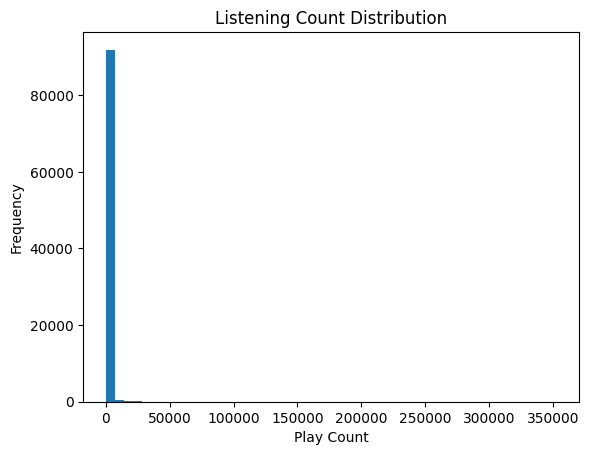

In [10]:
plt.hist(user_artists['weight'], bins=50)
plt.title("Listening Count Distribution")
plt.xlabel("Play Count")
plt.ylabel("Frequency")
plt.show()


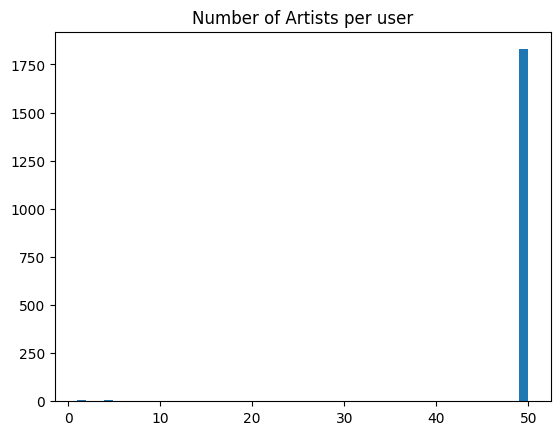

In [11]:
user_activity =user_artists.groupby('userID')['artistID'].count()
plt.hist(user_activity,bins=50)
plt.title("Number of Artists per user")
plt.show()

In [12]:
popular_artists = user_artists.groupby('artistID')['weight'].sum().sort_values(ascending=False).head(10)
popular_artist_names = artists[artists['id'].isin(popular_artists.index)]

popular_artist_names[['id','name']]


,id,name
61,67,Madonna
66,72,Depeche Mode
83,89,Lady Gaga
221,227,The Beatles
282,288,Rihanna
283,289,Britney Spears
286,292,Christina Aguilera
294,300,Katy Perry
492,498,Paramore
695,701,Shakira


In [13]:
user_artist_matrix = user_artists.pivot_table(index='userID',
                                              columns='artistID',
                                              values='weight',
                                              fill_value=0)
user_artist_matrix.shape


(1892, 17632)

In [14]:
user_artist_matrix.shape

(1892, 17632)

In [15]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
user_artist_scaled = pd.DataFrame(
    scaler.fit_transform(user_artist_matrix),
    index=user_artist_matrix.index,
    columns=user_artist_matrix.columns
)


In [16]:
artist_similarity = cosine_similarity(user_artist_scaled.T)
artist_similarity_df = pd.DataFrame(artist_similarity,
                                    index=user_artist_scaled.columns,
                                    columns=user_artist_scaled.columns)


In [17]:
def recommend_artists(user_id, n_recommendations=5):
    
    user_ratings = user_artist_scaled.loc[user_id]
    listened_artists = user_ratings[user_ratings > 0].index

    scores = pd.Series(0, index=user_artist_scaled.columns)

    for artist in listened_artists:
        similarity_scores = artist_similarity_df[artist]
        scores += similarity_scores * user_ratings[artist]

    scores = scores.drop(listened_artists)
    recommended_ids = scores.sort_values(ascending=False).head(n_recommendations).index

    recommendations = artists[artists['id'].isin(recommended_ids)][['id','name']]
    return recommendations


In [ ]:
recommendations = recommend_artists(2, 5)
print(recommendations)

        id                               name
984    993                       Simple Minds
989    998  Orchestral Manoeuvres in the Dark
992   1001                      Pet Shop Boys
1004  1013                           Ultravox
1113  1122                         The Police
